# Nonlinear activation-reader robustness

This notebook tests whether a predeclared PCA-plus-MLP reader changes the frozen Qwen conclusion. It is a decoder-capacity robustness test, not a search for H1.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Nonlinear activation-reader robustness on the frozen final Diplomacy bank

This notebook asks whether the final pre-action null/negative result is an artifact of restricting the neural decoder to a linear probe. It **does not regenerate states, model behavior, text observers, or activations**. It consumes the accepted 40-game run exactly as frozen.

### Predeclared nonlinear reader
For each decoder layer, fit a deterministic pipeline inside each training fold:

`StandardScaler -> PCA(<=16 components) -> one-hidden-layer tanh MLP (16 units, L2 alpha=1.0, LBFGS)`

Only the layer is selected by inner grouped cross-validation. Architecture, PCA size, activation, solver, regularization, and random seed are fixed before test-fold evaluation. This intentionally avoids a large post-hoc hyperparameter search.

### Primary robustness question
Does this fixed nonlinear reader beat the already-frozen fold-selected strong-text comparator on grouped held-out Brier score? A shuffled-label nonlinear reader is the negative control.


In [1]:
NOTEBOOK_BUILD="latent-reservations-p2-nonlinear-reader-robustness-v1"
print("="*104); print(NOTEBOOK_BUILD); print("="*104)


latent-reservations-p2-nonlinear-reader-robustness-v1


## 1. Dependencies and source-run integrity


In [2]:
from __future__ import annotations
import hashlib,json,os,sys,subprocess,zipfile
from datetime import datetime,timezone
from pathlib import Path
subprocess.run([sys.executable,"-m","pip","install","numpy<2","pandas>=2,<3","scikit-learn>=1.4,<2","scipy>=1.12,<2","safetensors>=0.4","matplotlib>=3.8,<4"],check=True)
import numpy as np,pandas as pd
PROJECT_ROOT=Path(os.environ.get("LR_PROJECT_ROOT","/workspace/latent-reservations")).expanduser().resolve()
SOURCE_RUN_ID=os.environ.get("LR_P2_SOURCE_NB19_RUN_ID","20260815T180359Z")
SOURCE_RUN_DIR=Path(os.environ.get("LR_P2_SOURCE_NB19_RUN_DIR",str(PROJECT_ROOT/"notebook_outputs"/"19_cicero_h1_activation_vs_strong_text"/SOURCE_RUN_ID))).expanduser().resolve()
EXPECTED_BANK_SHA="e21a88ae614279e2bde67554e8f788d28a7c6891b1ffb5cfd281a3bc23280900"
EXPECTED_PRED_SHA="37dbb5c46d782dd4d7c45a55fbc1a53a4fae7cd94558cf0d82e3ffe2a383ac48"
EXPECTED_ACT_SHA="5566b23c89106d9d32d91f625bf216d2da844760d41fe537cb22a8d4af8305b4"
for rel,expected in [("results/tables/source_state_bank_preoutcome.csv",EXPECTED_BANK_SHA),("results/tables/heldout_h1_predictions.csv",EXPECTED_PRED_SHA),("data/activations/pre_action_all_layers.safetensors",EXPECTED_ACT_SHA)]:
    p=SOURCE_RUN_DIR/rel
    if not p.exists(): raise FileNotFoundError(p)
    got=hashlib.sha256(p.read_bytes()).hexdigest()
    if got!=expected: raise RuntimeError(f"Frozen source hash mismatch for {rel}: {got}")
readiness=json.loads((SOURCE_RUN_DIR/"results/tables/readiness.json").read_text())
if readiness.get("experiment_valid_for_h1_inference") is not True: raise RuntimeError("Source run is not valid for H1 inference")
NOTEBOOK_SLUG="21_nonlinear_activation_reader_robustness"; RUN_ID=os.environ.get("LR_P2_RUN_ID",datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")); BASE=PROJECT_ROOT/"notebook_outputs"/NOTEBOOK_SLUG; RUN_DIR=BASE/RUN_ID; TABLE_DIR=RUN_DIR/"results/tables"; FIGURE_DIR=RUN_DIR/"results/figures"; MANIFEST_DIR=RUN_DIR/"manifests"
for p in [TABLE_DIR,FIGURE_DIR,MANIFEST_DIR]: p.mkdir(parents=True,exist_ok=True)
BASE.mkdir(parents=True,exist_ok=True); (BASE/"latest_run.json").write_text(json.dumps({"run_id":RUN_ID,"run_output_dir":str(RUN_DIR)},indent=2))
print({"source_run":str(SOURCE_RUN_DIR),"run_dir":str(RUN_DIR)})


{'source_run': '/workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z', 'run_dir': '/workspace/latent-reservations/notebook_outputs/21_nonlinear_activation_reader_robustness/20260816T085822Z'}


## 2. Freeze the nonlinear protocol


In [3]:
from sklearn.decomposition import PCA
from sklearn.metrics import brier_score_loss,accuracy_score,roc_auc_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from safetensors.torch import load_file

PCA_COMPONENTS=int(os.environ.get("LR_P2_PCA_COMPONENTS","16")); HIDDEN_UNITS=int(os.environ.get("LR_P2_HIDDEN_UNITS","16")); MLP_ALPHA=float(os.environ.get("LR_P2_MLP_ALPHA","1.0")); BOOTSTRAP_REPS=int(os.environ.get("LR_P2_BOOTSTRAP_REPS","20000")); SEED=int(os.environ.get("LR_SEED","20260815"))
if (PCA_COMPONENTS,HIDDEN_UNITS,MLP_ALPHA)!=(16,16,1.0):
    print("WARNING: protocol hyperparameters were overridden; treat this run as a sensitivity analysis rather than the locked P2 primary.")
protocol={"source_run":str(SOURCE_RUN_DIR),"reader":"StandardScaler -> PCA -> one-hidden-layer tanh MLP","pca_components":PCA_COMPONENTS,"hidden_units":HIDDEN_UNITS,"activation":"tanh","solver":"lbfgs","alpha":MLP_ALPHA,"only_tuned_dimension":"decoder layer via inner grouped folds","outer_folds":"frozen source-game folds","primary_metric":"Brier","primary_comparator":"frozen fold-selected strong text","negative_control":"same nonlinear pipeline with globally permuted labels","bootstrap":"source-game clustered 20,000 reps"}
(MANIFEST_DIR/"protocol_freeze.json").write_text(json.dumps(protocol,indent=2)); print(json.dumps(protocol,indent=2))


{
  "source_run": "/workspace/latent-reservations/notebook_outputs/19_cicero_h1_activation_vs_strong_text/20260815T180359Z",
  "reader": "StandardScaler -> PCA -> one-hidden-layer tanh MLP",
  "pca_components": 16,
  "hidden_units": 16,
  "activation": "tanh",
  "solver": "lbfgs",
  "alpha": 1.0,
  "only_tuned_dimension": "decoder layer via inner grouped folds",
  "outer_folds": "frozen source-game folds",
  "primary_metric": "Brier",
  "primary_comparator": "frozen fold-selected strong text",
  "negative_control": "same nonlinear pipeline with globally permuted labels",
  "bootstrap": "source-game clustered 20,000 reps"
}


## 3. Load exactly the frozen valid rows and activation tensor


In [4]:
pred=pd.read_csv(SOURCE_RUN_DIR/"results/tables/heldout_h1_predictions.csv")
valid=pd.read_csv(SOURCE_RUN_DIR/"results/tables/h1_valid_same_state_rows.csv")
act=load_file(str(SOURCE_RUN_DIR/"data/activations/pre_action_all_layers.safetensors"))["activations"].float().numpy()
if pred.state_id.tolist()!=valid.state_id.tolist(): raise RuntimeError("Prediction/valid-row order mismatch")
indices=valid.activation_index.astype(int).to_numpy(); X=act[indices]; y=pred.y_B.astype(int).to_numpy(); folds=pred.fold.astype(int).to_numpy(); groups=pred.game_index.astype(int).to_numpy()
if X.shape[0]!=len(y): raise RuntimeError("Activation/label row mismatch")
print({"rows":len(y),"source_games":len(np.unique(groups)),"activation_shape":list(X.shape),"A":int((y==0).sum()),"B":int((y==1).sum())})


{'rows': 76, 'source_games': 40, 'activation_shape': [76, 28, 3584], 'A': 29, 'B': 47}


## 4. Fixed nonlinear reader with nested grouped layer selection


In [5]:
def base_rate(labels): return float(np.mean(labels)) if len(labels) else .5

def fit_mlp(Xtr,ytr,Xt,seed):
    if len(np.unique(ytr))<2: return np.full(len(Xt),base_rate(ytr))
    ncomp=max(1,min(PCA_COMPONENTS,Xtr.shape[0]-2,Xtr.shape[1]))
    pipe=Pipeline([
        ("scale",StandardScaler()),
        ("pca",PCA(n_components=ncomp,svd_solver="randomized",random_state=int(seed))),
        ("mlp",MLPClassifier(hidden_layer_sizes=(HIDDEN_UNITS,),activation="tanh",solver="lbfgs",alpha=MLP_ALPHA,max_iter=5000,random_state=int(seed))),
    ])
    pipe.fit(Xtr,ytr); return pipe.predict_proba(Xt)[:,1]

def nested_mlp_predictions(acts,labels,folds,seed_offset=0):
    out=np.full(len(labels),np.nan); rows=[]; fold_values=sorted(set(int(x) for x in folds))
    for outer in fold_values:
        te=folds==outer; tr=folds!=outer; inner=[f for f in fold_values if f!=outer]; best=None
        for layer in range(acts.shape[1]):
            scores=[]
            for vf in inner:
                iv=folds==vf; it=tr&(folds!=vf)
                if not it.any() or not iv.any(): continue
                pp=fit_mlp(acts[it,layer,:],labels[it],acts[iv,layer,:],SEED+seed_offset+1000*outer+layer)
                scores.append(float(brier_score_loss(labels[iv],pp)))
            if scores:
                cand=(float(np.mean(scores)),int(layer))
                if best is None or cand<best: best=cand
        if best is None: continue
        inner_brier,layer=best; out[te]=fit_mlp(acts[tr,layer,:],labels[tr],acts[te,layer,:],SEED+seed_offset+100000+outer)
        rows.append({"outer_fold":outer,"selected_layer":layer,"inner_cv_brier":inner_brier})
    return out,pd.DataFrame(rows)

nonlinear_pred,fold_choices=nested_mlp_predictions(X,y,folds)
rng=np.random.default_rng(SEED+210001); shuffled_y=y[rng.permutation(len(y))]
shuffled_pred,shuffled_choices=nested_mlp_predictions(X,shuffled_y,folds,seed_offset=500000)
if not np.isfinite(nonlinear_pred).all() or not np.isfinite(shuffled_pred).all(): raise RuntimeError("Incomplete nonlinear predictions")
fold_choices.to_csv(TABLE_DIR/"nonlinear_nested_folds.csv",index=False); shuffled_choices.to_csv(TABLE_DIR/"shuffled_nonlinear_nested_folds.csv",index=False)
print(fold_choices.to_string(index=False))


 outer_fold  selected_layer  inner_cv_brier
          0              19        0.251709
          1              14        0.282369
          2               2        0.279480
          3               3        0.272518
          4              14        0.288268


## 5. Compare nonlinear, frozen linear, and frozen strong-text readers


In [6]:
def metrics(labels,p):
    p=np.clip(np.asarray(p,float),1e-6,1-1e-6); d={"brier":float(brier_score_loss(labels,p)),"accuracy":float(accuracy_score(labels,p>=.5)),"auroc":None}
    if len(np.unique(labels))==2: d["auroc"]=float(roc_auc_score(labels,p))
    return d
out=pred[["state_id","game_index","fold","y_B","p_activation","p_strong_text","p_matched_auditor","p_trained_text","p_constant","p_shuffled_activation"]].copy()
out["p_nonlinear"]=nonlinear_pred; out["p_shuffled_nonlinear"]=shuffled_pred
for name in ["activation","strong_text","matched_auditor","trained_text","constant","shuffled_activation","nonlinear","shuffled_nonlinear"]:
    out[f"se_{name}"]=(out.y_B-out[f"p_{name}"])**2
out["delta_strong_text_minus_nonlinear"]=out.se_strong_text-out.se_nonlinear
out["delta_linear_minus_nonlinear"]=out.se_activation-out.se_nonlinear
out.to_csv(TABLE_DIR/"nonlinear_heldout_predictions.csv",index=False)
all_metrics={n:metrics(y,out[f"p_{n}"]) for n in ["activation","nonlinear","strong_text","matched_auditor","trained_text","constant","shuffled_activation","shuffled_nonlinear"]}
print(pd.DataFrame(all_metrics).T.to_string())


                        brier  accuracy     auroc
activation           0.336488  0.552632  0.549523
nonlinear            0.425302  0.473684  0.386647
strong_text          0.240695  0.618421  0.468085
matched_auditor      0.285757  0.578947  0.552091
trained_text         0.240695  0.618421  0.468085
constant             0.237664  0.618421  0.436537
shuffled_activation  0.324009  0.539474  0.533382
shuffled_nonlinear   0.320460  0.605263  0.528980


## 6. Source-game clustered inference and decision


In [7]:
game=out.groupby("game_index",as_index=False).agg(delta_vs_text=("delta_strong_text_minus_nonlinear","mean"),delta_vs_linear=("delta_linear_minus_nonlinear","mean"))
rng=np.random.default_rng(SEED+210002)
def boot_ci(values):
    values=np.asarray(values,float); b=np.empty(BOOTSTRAP_REPS)
    for i in range(BOOTSTRAP_REPS): b[i]=rng.choice(values,size=len(values),replace=True).mean()
    return {"mean":float(b.mean()),"ci95_low":float(np.quantile(b,.025)),"ci95_high":float(np.quantile(b,.975)),"fraction_positive":float((b>0).mean())}
boot_text=boot_ci(game.delta_vs_text); boot_linear=boot_ci(game.delta_vs_linear)
beats_shuffle=all_metrics["nonlinear"]["brier"]<all_metrics["shuffled_nonlinear"]["brier"]
privileged=bool(beats_shuffle and game.delta_vs_text.mean()>0 and boot_text["ci95_low"]>0)
linear_improvement=bool(game.delta_vs_linear.mean()>0 and boot_linear["ci95_low"]>0)
if privileged: decision="nonlinear_reader_supports_privileged_access"
elif linear_improvement: decision="nonlinear_improves_on_linear_but_does_not_beat_strong_text"
else: decision="no_predeclared_nonlinear_rescue_of_linear_result"
result={"metrics":all_metrics,"delta_strong_text_minus_nonlinear":float(game.delta_vs_text.mean()),"bootstrap_vs_strong_text":boot_text,"delta_linear_minus_nonlinear":float(game.delta_vs_linear.mean()),"bootstrap_vs_linear":boot_linear,"nonlinear_beats_shuffled_control":beats_shuffle,"decision":decision,"claim_boundary":"A negative result applies only to this fixed one-hidden-layer PCA+MLP family on the frozen final-token activations."}
(TABLE_DIR/"nonlinear_result.json").write_text(json.dumps(result,indent=2)); game.to_csv(TABLE_DIR/"source_game_deltas.csv",index=False); print(json.dumps(result,indent=2))


{
  "metrics": {
    "activation": {
      "brier": 0.3364877773082724,
      "accuracy": 0.5526315789473685,
      "auroc": 0.549523110785033
    },
    "nonlinear": {
      "brier": 0.42530159976183374,
      "accuracy": 0.47368421052631576,
      "auroc": 0.38664710198092445
    },
    "strong_text": {
      "brier": 0.24069465053041061,
      "accuracy": 0.618421052631579,
      "auroc": 0.4680851063829787
    },
    "matched_auditor": {
      "brier": 0.2857565526315921,
      "accuracy": 0.5789473684210527,
      "auroc": 0.5520909757887014
    },
    "trained_text": {
      "brier": 0.24069465053041061,
      "accuracy": 0.618421052631579,
      "auroc": 0.4680851063829787
    },
    "constant": {
      "brier": 0.2376644694148255,
      "accuracy": 0.618421052631579,
      "auroc": 0.4365370506236244
    },
    "shuffled_activation": {
      "brier": 0.3240091300626679,
      "accuracy": 0.5394736842105263,
      "auroc": 0.5333822450476888
    },
    "shuffled_nonlinear": {
  

## 7. Figures and archive


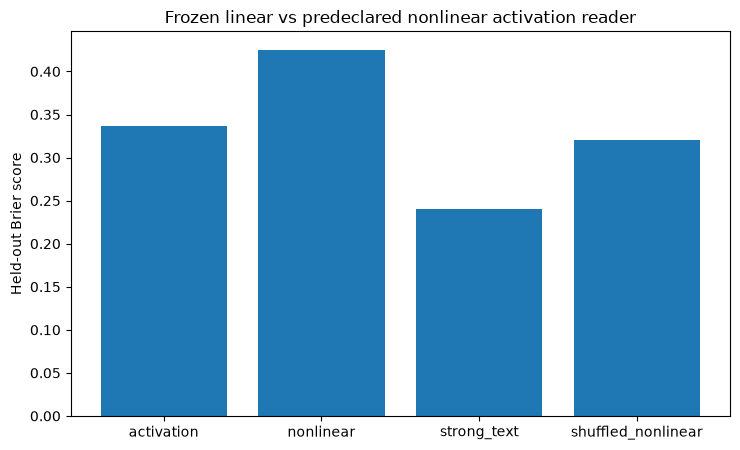

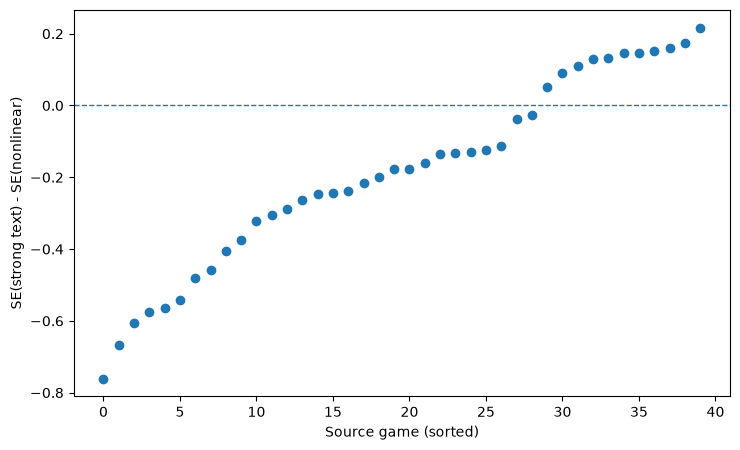

Decision: no_predeclared_nonlinear_rescue_of_linear_result
Archive: /workspace/latent-reservations/21_nonlinear_activation_reader_robustness_20260816T085822Z.zip


In [8]:
import matplotlib.pyplot as plt
names=["activation","nonlinear","strong_text","shuffled_nonlinear"]; fig,ax=plt.subplots(figsize=(7.5,4.6)); ax.bar(names,[all_metrics[n]["brier"] for n in names]); ax.set_ylabel("Held-out Brier score"); ax.set_title("Frozen linear vs predeclared nonlinear activation reader"); fig.tight_layout(); fig.savefig(FIGURE_DIR/"nonlinear_brier_comparison.png",dpi=180); plt.show()
fig,ax=plt.subplots(figsize=(7.5,4.6)); g=game.sort_values("delta_vs_text").reset_index(drop=True); ax.scatter(np.arange(len(g)),g.delta_vs_text); ax.axhline(0,ls="--",lw=1); ax.set_ylabel("SE(strong text) - SE(nonlinear)"); ax.set_xlabel("Source game (sorted)"); fig.tight_layout(); fig.savefig(FIGURE_DIR/"nonlinear_source_game_deltas.png",dpi=180); plt.show()
summary={"notebook_build":NOTEBOOK_BUILD,"run_id":RUN_ID,"source_run":str(SOURCE_RUN_DIR),"protocol":protocol,"result":result}
(TABLE_DIR/"result_summary.json").write_text(json.dumps(summary,indent=2)); (MANIFEST_DIR/"p2_manifest.json").write_text(json.dumps({"source_run":str(SOURCE_RUN_DIR),"predictions":str(TABLE_DIR/"nonlinear_heldout_predictions.csv"),"result":str(TABLE_DIR/"nonlinear_result.json")},indent=2))
checks=[]
for p in sorted(RUN_DIR.rglob("*")):
    if p.is_file(): checks.append({"path":str(p.relative_to(RUN_DIR)),"sha256":hashlib.sha256(p.read_bytes()).hexdigest(),"bytes":p.stat().st_size})
(RUN_DIR/"checksums.json").write_text(json.dumps(checks,indent=2)); archive=PROJECT_ROOT/f"21_nonlinear_activation_reader_robustness_{RUN_ID}.zip"
with zipfile.ZipFile(archive,"w",compression=zipfile.ZIP_DEFLATED) as zf:
    for p in sorted(RUN_DIR.rglob("*")):
        if p.is_file(): zf.write(p,arcname=str(Path(NOTEBOOK_SLUG)/RUN_ID/p.relative_to(RUN_DIR)))
print("Decision:",decision); print("Archive:",archive)
